# 02 · Modelado de tópicos

**Objetivo específico 2.** Determinar los temas emergentes mediante modelado de tópicos,
para representar los asuntos que abordan los comensales.

El notebook carga el modelo ya entrenado y congelado, describe sus 41 tópicos, presenta
la estructura de dos niveles que los agrupa en 14 temas y cierra con el análisis de
sensibilidad que delimita qué puede y qué no puede encontrar este método.

In [1]:
# Configuración local. El kernel es el del entorno de uv:
#     uv run python -m ipykernel install --user --name topicos-popayan
import sys
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
print(f"raíz del proyecto: {RAIZ}")

raíz del proyecto: /Users/noovou/dev/fup/topicos-popayan


In [2]:
import pandas as pd

from src.config import DATOS_PROCESADOS, SEMILLA
from src.embeddings import MODELO_EMBEDDINGS, obtener
from src.topicos import ATIPICO, MIN_SAMPLES, MIN_TOPIC_SIZE, UMBRAL_REDUCCION
from src.topicos import cargar_modelo_guardado

pd.set_option("display.max_colwidth", 110)

fragmentos = pd.read_csv(DATOS_PROCESADOS / "fragmentos.csv").merge(
    pd.read_csv(DATOS_PROCESADOS / "fragmentos_topicos.csv"),
    on=["fragmento_id", "review_id"],
)
etiquetas = pd.read_csv(DATOS_PROCESADOS / "topicos_etiquetados.csv")
print(f"{len(fragmentos)} fragmentos · {len(etiquetas)} tópicos")

5913 fragmentos · 41 tópicos


## 1. Embeddings

`paraphrase-multilingual-MiniLM-L12-v2` sobre la columna `texto`, que es el fragmento
enmascarado pero natural. Se calculan una sola vez y se guardan en disco junto a un
índice de `fragmento_id`; la función los **realinea por identificador, no por posición**,
así que reordenar el CSV no rompe la correspondencia.

Se comparó contra `intfloat/multilingual-e5-small` y se descartó: su espacio es muy
anisótropo —el coseno entre dos fragmentos cualesquiera está entre 0,79 y 0,89, contra
0,25 de media en MiniLM— y con el mismo umbral colapsa en 5 tópicos.

In [3]:
embeddings, info = obtener(fragmentos, MODELO_EMBEDDINGS)
print(f"modelo: {info['modelo']}")
print(f"matriz: {embeddings.shape}  ({info['dimension']} dimensiones)  origen: {info['origen']}")

modelo: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
matriz: (5913, 384)  (384 dimensiones)  origen: disco


## 2. Configuración congelada

| Componente | Valor |
|---|---|
| UMAP | `n_neighbors=15`, `n_components=5`, `min_dist=0.0`, coseno, `random_state=42` |
| HDBSCAN | `min_cluster_size=30`, `min_samples=15` |
| c-TF-IDF | `texto_limpio` con negaciones, unigramas y bigramas, `min_df=2` |
| Reducción de atípicos | estrategia `embeddings`, umbral 0,65 |
| Fusión | manual, un solo par (referente gastronómico de la ciudad) |

Dos parámetros merecen explicación porque no son los valores por defecto:

- **`min_samples=15`.** Con `min_cluster_size=50` el modelo minimizaba la partición por
  tono, pero solo porque fundía todo lo negativo en un cajón del 26,9 % del corpus con
  rating 2,40. La métrica premiaba el defecto.
- **Umbral de reducción 0,65.** El de BERTopic (0,30) reasigna el 99 % de los atípicos
  pero mal: metía «Volveremos» en el tópico de quejas. 0,65 queda justo bajo el coseno
  medio de los fragmentos ya asignados a su centroide (0,676), de modo que un atípico se
  reasigna solo si encaja tan bien como uno típico.

In [4]:
modelo = cargar_modelo_guardado()
asignados = int((fragmentos["topico"] != ATIPICO).sum())
print(f"min_cluster_size={MIN_TOPIC_SIZE} · min_samples={MIN_SAMPLES} · "
      f"umbral_reduccion={UMBRAL_REDUCCION} · semilla={SEMILLA}")
print(f"\ntópicos: {len(etiquetas)}")
print(f"asignados: {asignados} ({100 * asignados / len(fragmentos):.1f} %)")
print(f"atípicos:  {len(fragmentos) - asignados} "
      f"({100 * (1 - asignados / len(fragmentos)):.1f} %)")

min_cluster_size=30 · min_samples=15 · umbral_reduccion=0.65 · semilla=42

tópicos: 41
asignados: 4772 (80.7 %)
atípicos:  1141 (19.3 %)


## 3. Los 41 tópicos

Ordenados por tamaño, con su tema, polaridad y calificación media. Los umbrales de
polaridad son **positiva ≥ 4,2 · negativa ≤ 2,5 · mixta en el resto**, y son
convencionales: se declaran para que el lector sepa de dónde sale la etiqueta.

In [5]:
tabla = etiquetas.sort_values("n", ascending=False)[
    ["topico_id", "tema", "subtema", "tipo", "polaridad", "n", "pct_corpus",
     "rating", "pct_1_2_estrellas"]
].fillna("")
tabla

,topico_id,tema,subtema,tipo,polaridad,n,pct_corpus,rating,pct_1_2_estrellas
0,0,espera,,atributo_esquema,negativa,355,6.00,1.88,75.8
1,1,servicio,,atributo_esquema,mixta,355,6.00,4.09,18.6
2,2,ambiente,,atributo_esquema,positiva,334,5.65,4.34,11.1
3,3,experiencia global,,valoracion_global,positiva,296,5.01,4.75,2.7
4,4,comida,,atributo_esquema,positiva,265,4.48,4.26,12.8
5,5,recomendacion,,valoracion_global,mixta,263,4.45,4.03,18.6
6,6,comida,,atributo_esquema,negativa,212,3.59,1.98,71.7
7,7,servicio,,atributo_esquema,positiva,187,3.16,4.79,2.1
8,8,ocasion de consumo,,atributo_nuevo,positiva,155,2.62,4.48,7.1
9,9,referente en la ciudad,,atributo_nuevo,positiva,154,2.60,4.40,11.0


## 4. Términos y ejemplos de los tópicos mayores

Los términos vienen del c-TF-IDF sobre `texto_limpio`; los ejemplos son una muestra
aleatoria reproducible de cada tópico, **no** los documentos representativos de
BERTopic, para no sesgar la lectura hacia el centro del tópico.

La evidencia completa de los 41 tópicos, con cinco fragmentos cada uno, está en
`docs/evidencia_topicos.md`.

In [6]:
nombres = etiquetas.set_index("topico_id")

def describir(topico, n_ejemplos=3):
    sub = fragmentos[fragmentos["topico"] == topico]
    fila = nombres.loc[topico]
    subtema = fila["subtema"] if isinstance(fila["subtema"], str) and fila["subtema"] else ""
    titulo = f"T{topico} · {fila['tema']}" + (f" / {subtema}" if subtema else "")
    terminos = [t for t, _ in (modelo.get_topic(topico) or [])][:8]
    print(f"{titulo}  (n={len(sub)}, rating {fila['rating']}, {fila['polaridad']})")
    print(f"   {', '.join(terminos)}")
    for texto in sub.sample(n_ejemplos, random_state=SEMILLA)["texto"]:
        print(f"   · {texto[:120]}")
    print()

for topico in etiquetas.nlargest(8, "n")["topico_id"]:
    describir(topico)

T0 · espera  (n=355, rating 1.88, negativa)
   hora, pedido, minutos, no, horas, esperando, después, demora
   · Pedí un plato a la 1:00 pm, éramos varios, pregunté varias veces por mi platillo y no me servían
   · Se esperó más o menos 2 horas para el pedido, sirven platos fríos (churrascos, baby beef, etc), una casuela de frijoles 
   · Quedé mal con mi invitada

T1 · servicio  (n=355, rating 4.09, mixta)
   servicio, atención, buena, personal, buena atención, servicio atención, atento, rápido
   · El servicio es bueno
   · Cero recomendado, mejorar el servicio por favor
   · La atención es amable y atenta, siempre con una sonrisa y con ese cuidado que hace que uno se sienta bienvenido y en bue

T2 · ambiente  (n=334, rating 4.34, positiva)
   lugar, agradable, ambiente, sitio, decoración, acogedor, lugar agradable, bonito
   · Es un lugar inmenso y espectacular, con reservados semiprivados para grupos de hasta 10 personas
   · Sin duda, un lugar que combina tradición y eficiencia
  

## 5. Estructura de dos niveles

Los 41 tópicos se agrupan en **14 temas**, clasificados en tres tipos:

- **`atributo_esquema`** — habla de una de las seis dimensiones a priori.
- **`atributo_nuevo`** — habla de un atributo que el esquema no contempla.
- **`valoracion_global`** — no describe ningún atributo, emite un veredicto sobre la
  experiencia.

La asignación es manual, hecha leyendo términos y fragmentos, y vive en
`src/etiquetas.py` para que sea revisable y reversible. El modelo no se modifica.

In [7]:
temas = pd.read_csv(DATOS_PROCESADOS / "temas_consolidado.csv")
temas[["tema", "tipo", "n_topicos", "fragmentos", "pct_asignado",
       "rating", "pct_1_2_estrellas", "polaridad_dominante"]]

,tema,tipo,n_topicos,fragmentos,pct_asignado,rating,pct_1_2_estrellas,polaridad_dominante
0,comida,atributo_esquema,16,1500,31.4,3.83,23.9,mixta
1,servicio,atributo_esquema,4,690,14.5,3.78,26.5,mixta
2,experiencia global,valoracion_global,5,526,11.0,4.12,18.8,positiva
3,espera,atributo_esquema,1,355,7.4,1.88,75.8,negativa
4,recomendacion,valoracion_global,3,347,7.3,3.47,33.1,mixta
5,ambiente,atributo_esquema,1,334,7.0,4.34,11.1,positiva
6,referente en la ciudad,atributo_nuevo,2,276,5.8,4.55,7.2,positiva
7,ocasion de consumo,atributo_nuevo,2,223,4.7,4.58,4.9,positiva
8,patrimonio,atributo_esquema,2,161,3.4,4.45,11.8,positiva
9,precio,atributo_esquema,1,140,2.9,3.70,25.0,mixta


In [8]:
por_tipo = temas.groupby("tipo").agg(
    topicos=("n_topicos", "sum"), fragmentos=("fragmentos", "sum")
)
por_tipo["% del corpus asignado"] = (100 * por_tipo["fragmentos"] / asignados).round(1)
por_tipo.sort_values("fragmentos", ascending=False)

,topicos,fragmentos,% del corpus asignado
tipo,,,
atributo_esquema,25,3180,66.6
valoracion_global,10,970,20.3
atributo_nuevo,6,622,13.0


**Un quinto del corpus asignado no describe ningún atributo.** Son 970 fragmentos de
valoración global, recomendación, intención de volver y satisfacción. Para el objetivo 3
no tienen con qué contrastarse, porque no describen un aspecto de la experiencia sino un
veredicto sobre ella.

Los **atributos emergentes** son el 13,0 % del corpus asignado: ocasión de consumo,
referente en la ciudad, infraestructura y espacio, y medios de pago. Ninguno cabe en las
seis dimensiones.

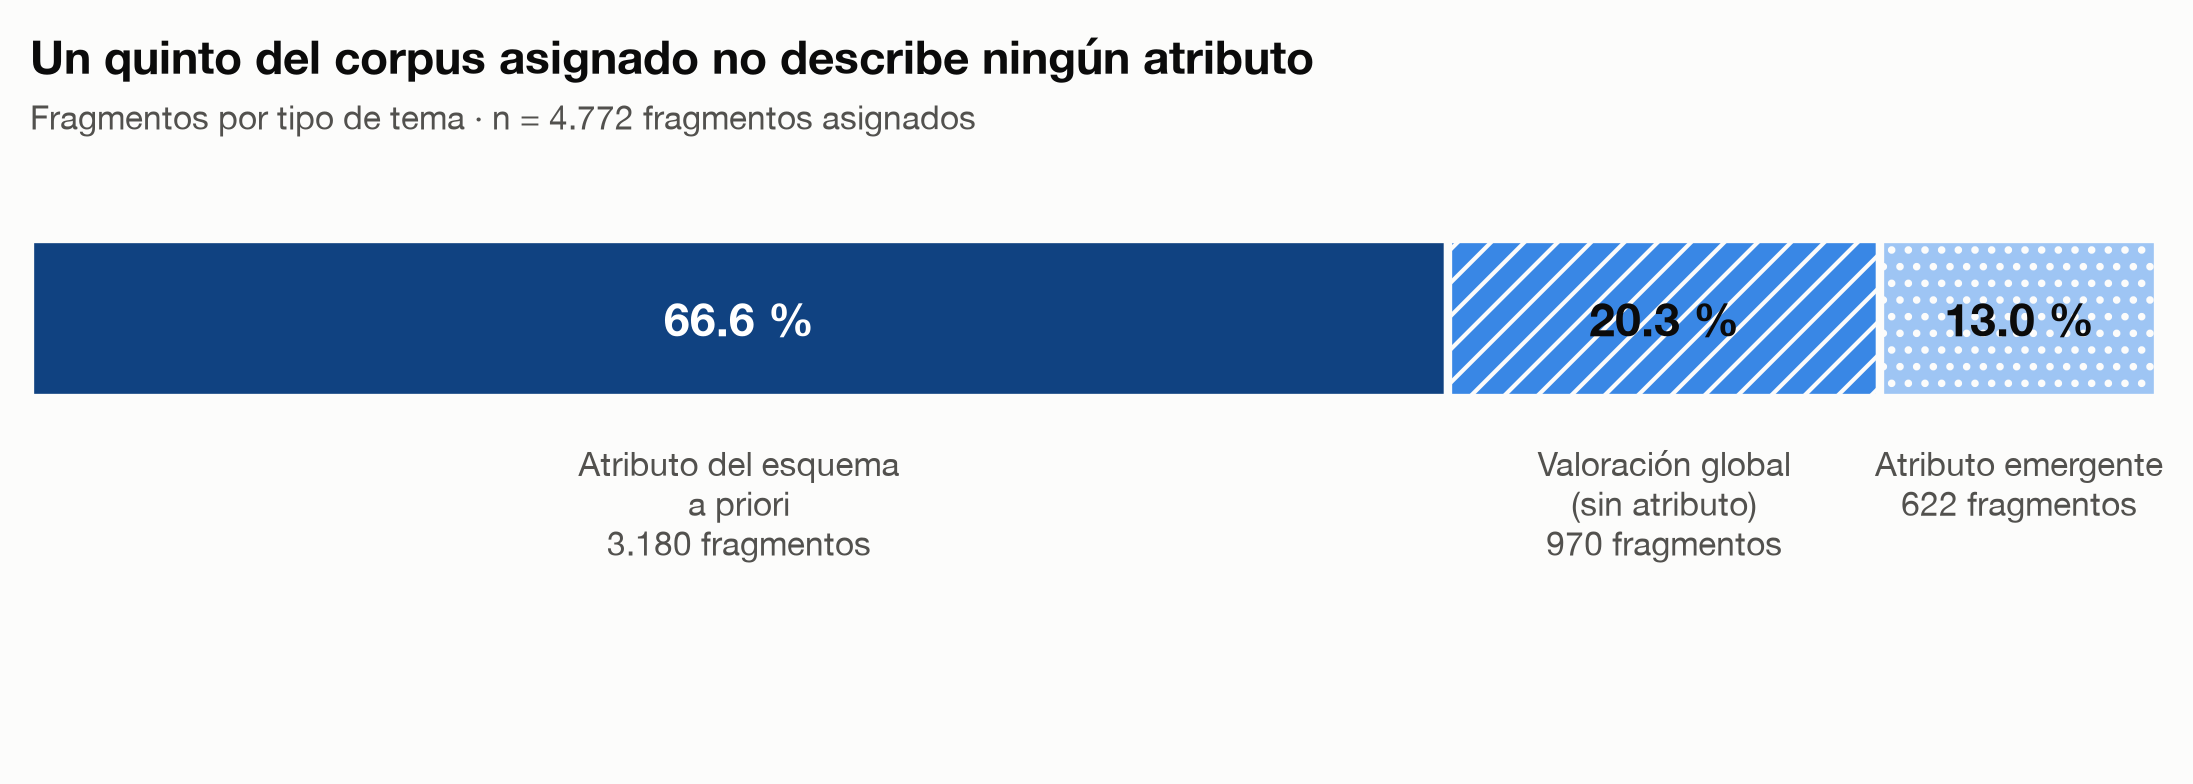

In [9]:
from IPython.display import Image, display
from src.config import FIGURAS

display(Image(filename=str(FIGURAS / "01_distribucion_por_tipo.png"), width=900))

### Una asimetría con consecuencias

Ninguno de los seis tópicos de tipo `atributo_nuevo` es negativo. No significa que no
haya quejas sobre atributos nuevos —inocuidad y cobro son de los temas más negativos del
corpus— sino que **los atributos emergentes que alcanzaron masa y cohesión para formar
tópico son los positivos**. Interpretar los atributos emergentes solo por los tópicos
formados subestimaría sistemáticamente lo negativo.

In [10]:
polaridad = temas.pivot_table(index="tipo", columns="polaridad_dominante",
                              values="fragmentos", aggfunc="sum", fill_value=0)
polaridad

polaridad_dominante,mixta,negativa,positiva
tipo,,,
atributo_esquema,2330,355,495
atributo_nuevo,123,0,499
valoracion_global,347,0,623


## 6. Análisis de sensibilidad: qué NO puede encontrar este método

Cuatro temas aparecieron al leer los atípicos —inocuidad, honestidad en el cobro,
horarios e información digital, infraestructura frente al clima— pero **ninguno forma
tópico propio**. La hipótesis inicial fue que se debía al umbral de tamaño mínimo. Se
puso a prueba corriendo la misma configuración con `min_cluster_size` en 20 y en 15.

Un tema «forma tópico propio» si existe un tópico donde al menos el 25 % de sus
fragmentos son del tema y que concentra al menos el 20 % del tema.

In [11]:
sensibilidad = pd.read_csv(DATOS_PROCESADOS / "sensibilidad_umbral.csv")
sensibilidad

,min_cluster_size,min_samples,congelada,n_topicos,pct_atipicos,pct_topico_mayor,inocuidad_forma_topico,inocuidad_max_concentracion,honestidad_forma_topico,honestidad_max_concentracion,horarios_forma_topico,horarios_max_concentracion
0,30,15,True,42,19.3,6.0,False,26.4,False,9.6,False,38.3
1,20,10,False,74,19.2,4.4,False,11.3,False,7.7,False,21.3
2,15,7,False,100,15.2,4.2,False,11.3,False,9.6,False,12.8


**La hipótesis no se sostiene: bajar el umbral no los agrupa, los dispersa más.** La
concentración de cada tema en su tópico mayor *cae* al bajar `min_cluster_size` —de
26,4 % a 11,3 % en inocuidad, de 38,3 % a 12,8 % en horarios.

La causa real es la **cohesión** en el espacio de embeddings, no la masa. Se compara la
similitud media entre los pares de cada grupo contra una línea base de grupos aleatorios
del mismo tamaño.

In [12]:
cohesion = pd.read_csv(DATOS_PROCESADOS / "cohesion_temas.csv")
cohesion

,grupo,origen,n,cohesion,nulo,exceso
0,T15 comida / pizza,topico del modelo,100,0.682,0.247,0.435
1,T40 medios de pago,topico del modelo,34,0.586,0.250,0.336
2,T17 patrimonio,topico del modelo,82,0.547,0.248,0.299
3,T0 espera,topico del modelo,355,0.376,0.248,0.128
4,T16 infraestructura y espacio,topico del modelo,89,0.364,0.249,0.115
5,inocuidad,regla de recuperacion,53,0.351,0.250,0.101
6,honestidad en el cobro,regla de recuperacion,52,0.336,0.247,0.089
7,infraestructura y clima,regla de recuperacion,11,0.267,0.244,0.023
8,horarios e informacion digital,regla de recuperacion,47,0.261,0.247,0.014


La comparación decisiva es **medios de pago contra inocuidad**: medios de pago tiene 34
fragmentos, menos que los 53 de inocuidad, y aun así formó tópico propio con
`min_cluster_size=30`, porque su exceso de cohesión sobre el azar es +0,336 contra
+0,101.

La explicación es que el embedding agrupa por lo que la cláusula *dice*, no por la marca
superficial que usa la regla de búsqueda. Una queja por moho es, semánticamente, una
queja sobre el plato, y cae junto a las demás quejas sobre platos. «No tienen datáfono»,
en cambio, no se parece a nada más del corpus, y por eso se agrupa.

## Hallazgos

1. **Emergen 41 tópicos que se agrupan en 14 temas**, sobre el 80,7 % del corpus. El
   tópico mayor es solo el 6,0 %, así que no hay ningún cajón que acapare la solución.

2. **Los temas emergentes existen y son cuatro:** ocasión de consumo, referente
   gastronómico de la ciudad, infraestructura y espacio, y medios de pago. Suman el
   13,0 % del corpus asignado y ninguno cabe en las seis dimensiones a priori. Dos de
   ellos —medios de pago e infraestructura— son además invisibles para el diccionario:
   el 91 % y el 76 % de sus fragmentos no activan ninguna dimensión.

3. **Un quinto del corpus asignado no habla de atributos**, sino que emite veredictos.
   Es un hallazgo sobre el género discursivo de la reseña, y limita lo que el objetivo 3
   puede contrastar.

4. **Los atributos emergentes que el método encuentra son sistemáticamente los
   positivos.** Los negativos —inocuidad, cobro, horarios— existen en el corpus pero no
   forman tópico.

5. **Y no lo forman por cohesión, no por masa.** El análisis de sensibilidad descarta la
   explicación del umbral: bajar `min_cluster_size` los dispersa más. Son **temas
   transversales**, que atraviesan cláusulas de asuntos distintos en vez de constituir un
   asunto propio. El modelado de tópicos es la herramienta equivocada para ellos, y hay
   que sostenerlos con reglas de recuperación y análisis cualitativo.

---

*Este notebook lee de `data/processed/` los resultados ya calculados. Los scripts que
los producen están en `scripts/` y las decisiones que los sustentan, con sus cifras, en
`docs/bitacora.md` y `docs/decisiones_metodologicas.md`.*